In [1]:
# ============================================================
# PHASE 1 — DATA LOADING & CLEANING
# CAPSTONE: Predicting Diabetic Patient Readmission Risk
# Author: Akshara Miriyala | MS Business Analytics | UC
# ============================================================

# ── STEP 1: Import Libraries ──────────────────────────────
# These are all the tools we need for the entire project
# We import everything upfront so nothing breaks later

import pandas as pd               # for loading and manipulating data
import numpy as np                # for numerical operations
import matplotlib.pyplot as plt   # for creating plots
import seaborn as sns             # for beautiful statistical plots
import warnings
warnings.filterwarnings('ignore') # suppress unnecessary warnings

print("All libraries loaded successfully!")

# ── STEP 2: Load the Dataset ──────────────────────────────
# pd.read_csv reads your CSV file into a DataFrame
# na_values='?' tells pandas to treat '?' as missing values
# because in this dataset missing values are coded as '?'

df = pd.read_csv('data/diabetic_data.csv', na_values='?')

print(f"\nDataset shape: {df.shape}")
# Expected output: (101766, 50)
# 101,766 patient encounters | 50 features

print("\nFirst 3 rows:")
print(df.head(3))

All libraries loaded successfully!

Dataset shape: (101766, 50)

First 3 rows:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)    NaN   
1        149190     55629189        Caucasian  Female  [10-20)    NaN   
2         64410     86047875  AfricanAmerican  Female  [20-30)    NaN   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No   
1                 3  ...          No      Up                   No   
2                 2  ...          No      No                   No   

   glipizide-metformin  glimepiride-pioglitazone  metformin-rosigl

In [2]:
# ── STEP 3: Understand Missing Values ─────────────────────
# Let's see which columns have missing data and how much

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("Columns with missing values:")
print(missing_df[missing_df['Missing Count'] > 0])

Columns with missing values:
                   Missing Count  Missing %
weight                     98569  96.858479
max_glu_serum              96420  94.746772
A1Cresult                  84748  83.277322
medical_specialty          49949  49.082208
payer_code                 40256  39.557416
race                        2273   2.233555
diag_3                      1423   1.398306
diag_2                       358   0.351787
diag_1                        21   0.020636


In [3]:
# ── STEP 4: Drop Columns with Too Many Missing Values ─────
# weight: 97% missing — useless, drop it
# payer_code: 40% missing — not clinically relevant, drop it
# medical_specialty: 49% missing — too many gaps, drop it

df.drop(columns=['weight', 'payer_code', 'medical_specialty'], inplace=True)
print("Dropped 3 high-missing columns")

# ── STEP 5: Drop Irrelevant ID Columns ────────────────────
# encounter_id and patient_nbr are just ID numbers
# They have no predictive value — like a student ID number
# A model should never learn from IDs

df.drop(columns=['encounter_id', 'patient_nbr'], inplace=True)
print("Dropped 2 ID columns")

# ── STEP 6: Handle Remaining Missing Values ───────────────
# race has a small % missing — fill with 'Unknown'
# This is safer than dropping 2000+ rows of good data

df['race'].fillna('Unknown', inplace=True)
print("Filled missing race values with 'Unknown'")

# ── STEP 7: Remove Invalid Gender Rows ────────────────────
# A tiny number of rows have gender = 'Unknown/Invalid'
# These are data entry errors — safe to remove

df = df[df['gender'] != 'Unknown/Invalid']
print(f"Removed invalid gender rows")

# ── STEP 8: Remove Duplicate Patients ─────────────────────
# Some patients appear multiple times
# We keep only their FIRST encounter to avoid data leakage
# Data leakage = model sees future info it shouldn't have

# We need patient_nbr for this — reload it temporarily
df_raw = pd.read_csv('data/diabetic_data.csv', na_values='?')
first_encounters = df_raw.groupby('patient_nbr')['encounter_id'].min().values
df_raw = df_raw[df_raw['encounter_id'].isin(first_encounters)]

# Now redo the cleaning on this deduplicated version
df = df_raw.copy()
df.drop(columns=['weight', 'payer_code', 'medical_specialty',
                 'encounter_id', 'patient_nbr'], inplace=True)
df['race'].fillna('Unknown', inplace=True)
df = df[df['gender'] != 'Unknown/Invalid']

print(f"\nFinal cleaned shape: {df.shape}")
print("Each patient now appears exactly once")

# ── STEP 9: Create the Target Variable ────────────────────
# Original column 'readmitted' has 3 values:
#   '<30'  = readmitted within 30 days  ← this is what we want to predict
#   '>30'  = readmitted after 30 days
#   'NO'   = never readmitted
#
# We convert this to binary:
#   1 = readmitted within 30 days (the HIGH RISK patients)
#   0 = everything else

df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

print(f"\nTarget variable distribution:")
print(df['readmitted_binary'].value_counts())
print(f"\nReadmission rate: {df['readmitted_binary'].mean()*100:.1f}%")

# Drop the original readmitted column — we have our binary version now
df.drop(columns=['readmitted'], inplace=True)

print("\nPhase 1 Complete! Data is clean and ready.")
print(f"Final dataset: {df.shape[0]} patients, {df.shape[1]} features")

Dropped 3 high-missing columns
Dropped 2 ID columns
Filled missing race values with 'Unknown'
Removed invalid gender rows

Final cleaned shape: (71515, 45)
Each patient now appears exactly once

Target variable distribution:
readmitted_binary
0    65222
1     6293
Name: count, dtype: int64

Readmission rate: 8.8%

Phase 1 Complete! Data is clean and ready.
Final dataset: 71515 patients, 45 features


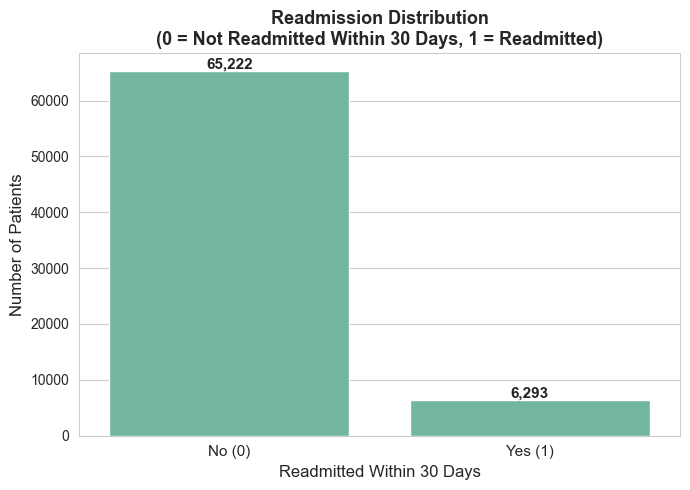

Plot 1 saved: Target Distribution


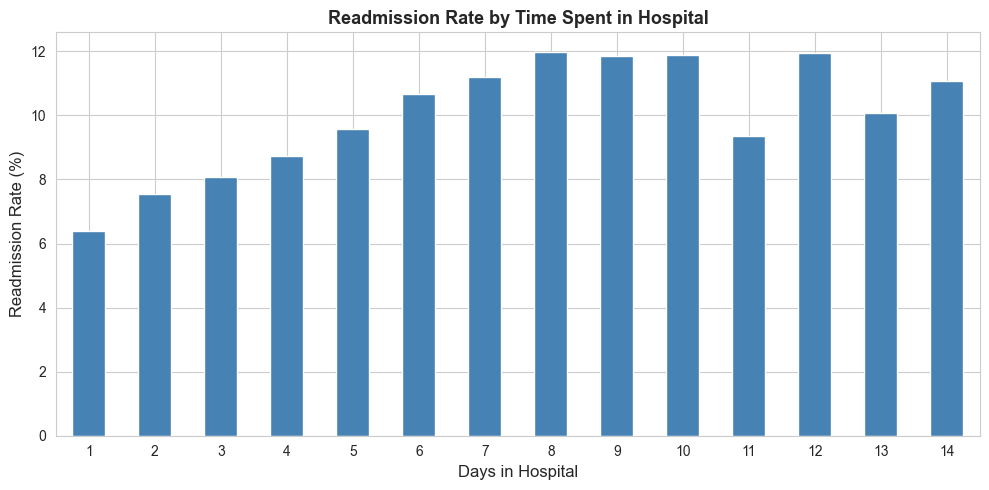

Plot 2 saved: Readmission by Time in Hospital


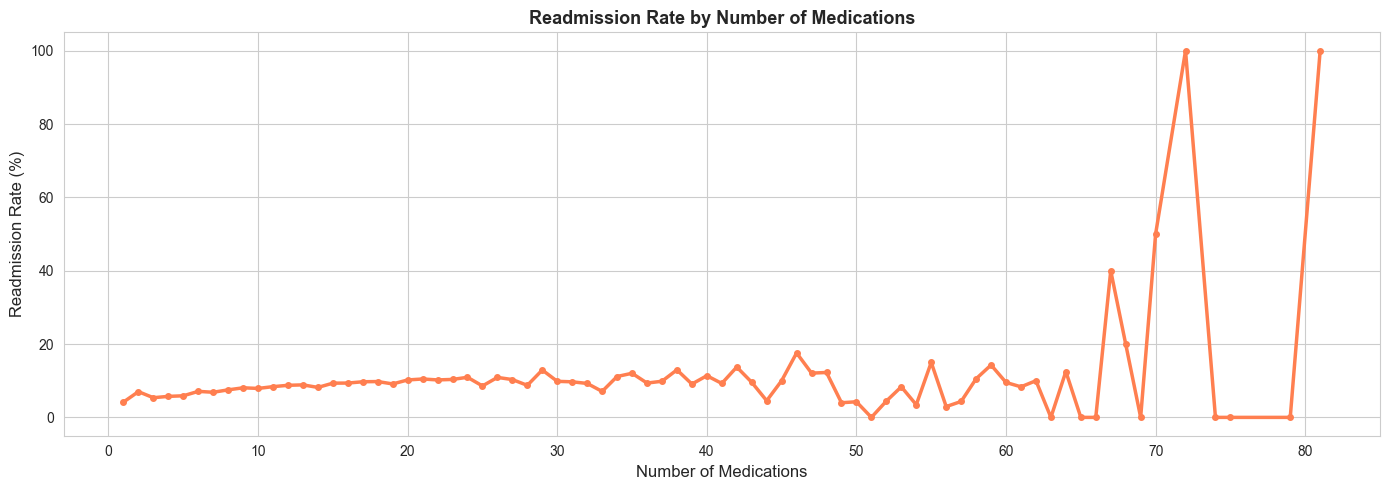

Plot 3 saved: Readmission by Medications


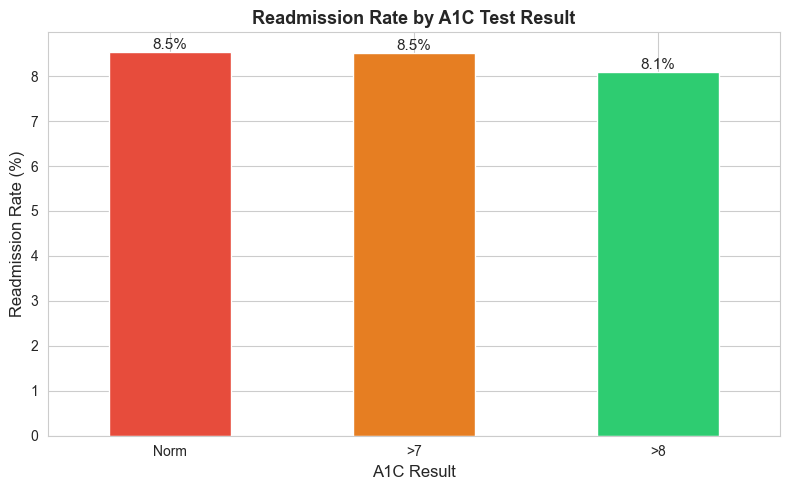

Plot 4 saved: Readmission by A1C Result


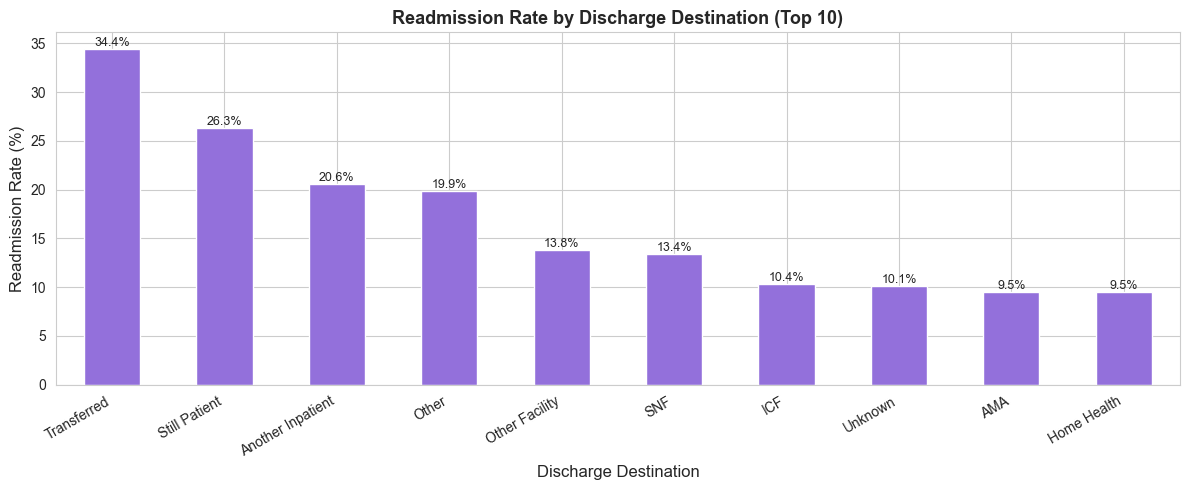

Plot 5 saved: Readmission by Discharge Disposition


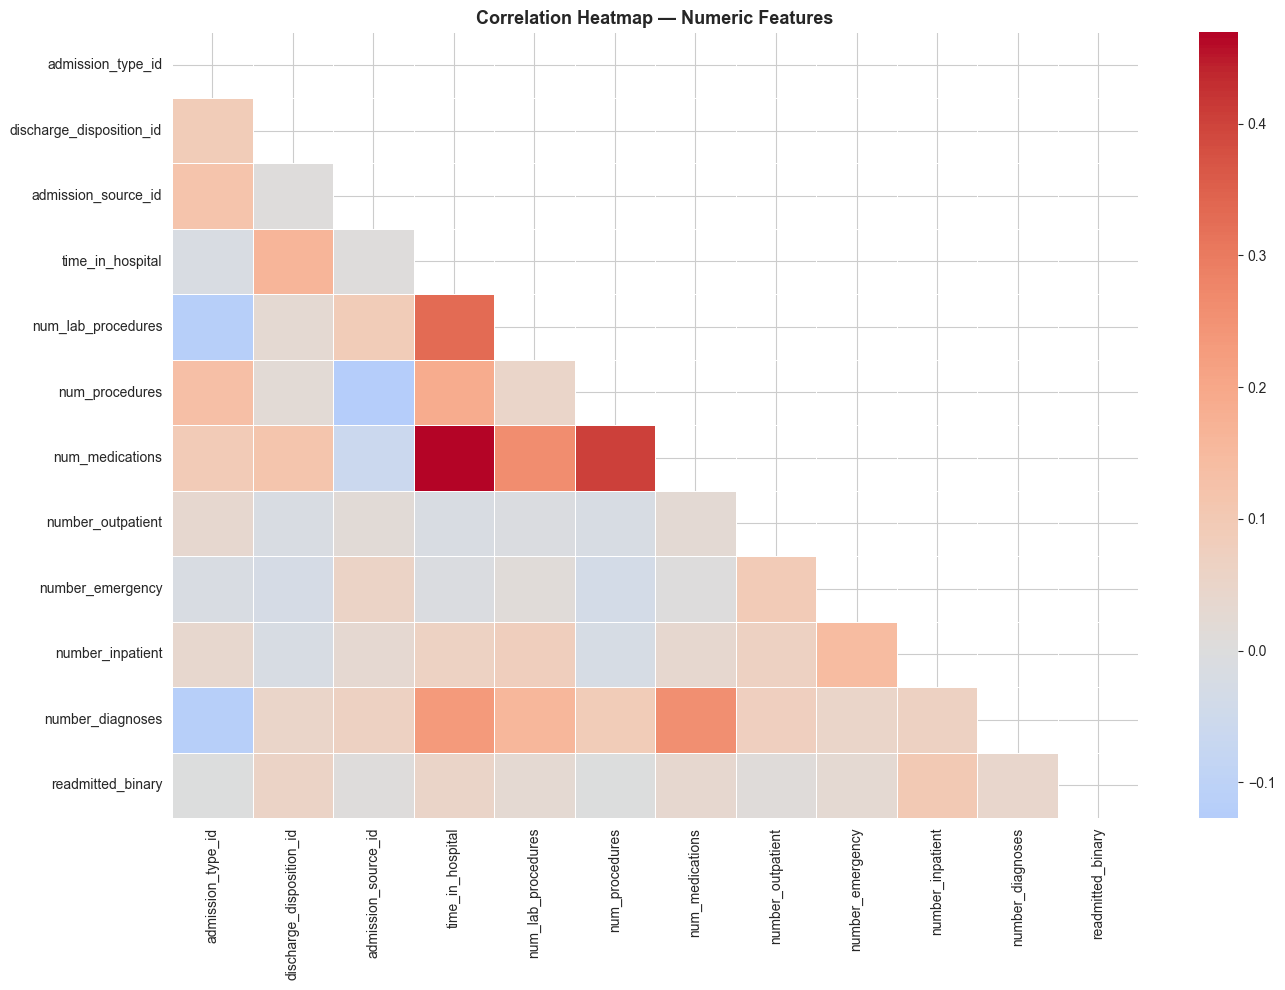

Plot 6 saved: Correlation Heatmap


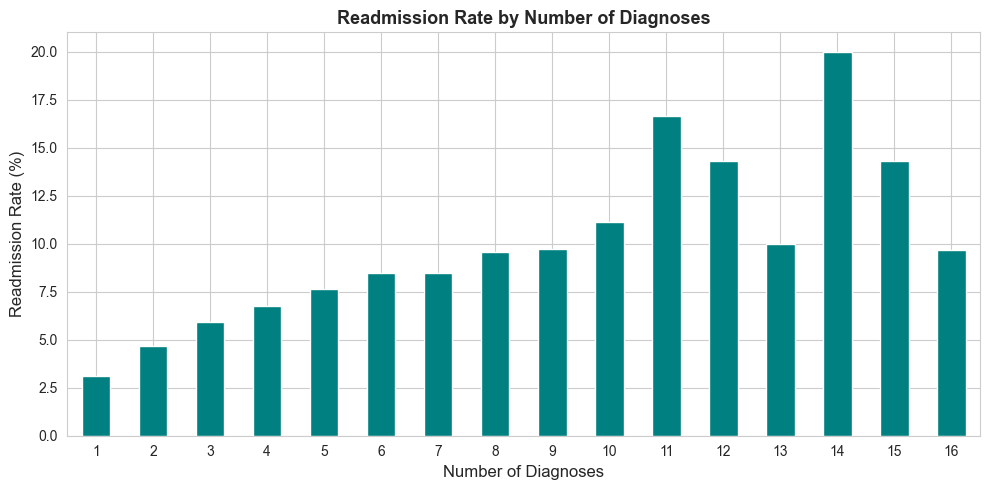

Plot 7 saved: Readmission by Number of Diagnoses

PHASE 2 COMPLETE — All 7 EDA plots saved!
Check your outputs/ folder to see all charts


In [6]:
# ============================================================
# PHASE 2 — EXPLORATORY DATA ANALYSIS (EDA)
# Goal: Understand the data visually BEFORE modeling
# Every plot saves to your outputs/ folder automatically
# ============================================================

import os
os.makedirs('outputs', exist_ok=True)  # make sure outputs folder exists

# Set a clean visual style for all plots
sns.set_style("whitegrid")
sns.set_palette("Set2")

# ── PLOT 1: Target Variable Distribution ──────────────────
# Shows how many patients were readmitted vs not
# This visually confirms our 8.8% imbalance

plt.figure(figsize=(7, 5))
ax = sns.countplot(x='readmitted_binary', data=df)
plt.title('Readmission Distribution\n(0 = Not Readmitted Within 30 Days, 1 = Readmitted)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Readmitted Within 30 Days', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks([0, 1], ['No (0)', 'Yes (1)'], fontsize=11)

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/fig1_target_distribution.png', dpi=150)
plt.show()
print("Plot 1 saved: Target Distribution")

# ── PLOT 2: Readmission Rate by Time in Hospital ──────────
# Key clinical question: do longer stays = more readmissions?
# This is one of our most important predictors

plt.figure(figsize=(10, 5))
readmit_by_time = df.groupby('time_in_hospital')['readmitted_binary'].mean() * 100
readmit_by_time.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Readmission Rate by Time Spent in Hospital', 
          fontsize=13, fontweight='bold')
plt.xlabel('Days in Hospital', fontsize=12)
plt.ylabel('Readmission Rate (%)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/fig2_readmission_by_time.png', dpi=150)
plt.show()
print("Plot 2 saved: Readmission by Time in Hospital")

# ── PLOT 3: Readmission Rate by Number of Medications ─────
# More medications = sicker patient = higher readmission?
# This is a key discharge decision variable

plt.figure(figsize=(14, 5))
readmit_by_meds = df.groupby('num_medications')['readmitted_binary'].mean() * 100
readmit_by_meds.plot(kind='line', color='coral', linewidth=2.5, marker='o', markersize=4)
plt.title('Readmission Rate by Number of Medications', 
          fontsize=13, fontweight='bold')
plt.xlabel('Number of Medications', fontsize=12)
plt.ylabel('Readmission Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/fig3_readmission_by_medications.png', dpi=150)
plt.show()
print("Plot 3 saved: Readmission by Medications")

# ── PLOT 4: Readmission Rate by A1C Test Result ───────────
# A1C measures average blood sugar over 3 months
# This is THE most important lab test for diabetics
# Key question: does ordering/not ordering A1C affect readmission?

plt.figure(figsize=(8, 5))
readmit_by_a1c = df.groupby('A1Cresult')['readmitted_binary'].mean() * 100
readmit_by_a1c = readmit_by_a1c.sort_values(ascending=False)
ax = readmit_by_a1c.plot(kind='bar', color=['#e74c3c','#e67e22','#2ecc71','#3498db'], 
                          edgecolor='white')
plt.title('Readmission Rate by A1C Test Result', 
          fontsize=13, fontweight='bold')
plt.xlabel('A1C Result', fontsize=12)
plt.ylabel('Readmission Rate (%)', fontsize=12)
plt.xticks(rotation=0)

# Add % labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('outputs/fig4_readmission_by_a1c.png', dpi=150)
plt.show()
print("Plot 4 saved: Readmission by A1C Result")

# ── PLOT 5: Readmission Rate by Discharge Disposition ─────
# Discharge disposition = where the patient went after hospital
# e.g. home, skilled nursing facility, another hospital
# This is the single most actionable clinical decision variable

# First map the numeric codes to readable labels
discharge_map = {
    1: 'Home', 2: 'Other Facility', 3: 'SNF', 4: 'ICF',
    5: 'Another Inpatient', 6: 'Home Health', 7: 'AMA',
    11: 'Expired', 13: 'Hospice', 14: 'Hospice Facility',
    18: 'Unknown', 19: 'Expired at Home', 20: 'Expired Inpatient',
    21: 'Expired Outpatient', 22: 'Still Patient', 23: 'Expired Place',
    24: 'Expired Place', 25: 'Not Mapped', 26: 'Unknown',
    27: 'Transferred', 28: 'Transferred', 29: 'Transferred',
    30: 'Still Patient'
}
df['discharge_label'] = df['discharge_disposition_id'].map(discharge_map).fillna('Other')

plt.figure(figsize=(12, 5))
readmit_by_discharge = df.groupby('discharge_label')['readmitted_binary'].mean() * 100
readmit_by_discharge = readmit_by_discharge.sort_values(ascending=False).head(10)
ax = readmit_by_discharge.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Readmission Rate by Discharge Destination (Top 10)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Discharge Destination', fontsize=12)
plt.ylabel('Readmission Rate (%)', fontsize=12)
plt.xticks(rotation=30, ha='right')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/fig5_readmission_by_discharge.png', dpi=150)
plt.show()
print("Plot 5 saved: Readmission by Discharge Disposition")

# ── PLOT 6: Correlation Heatmap ───────────────────────────
# Shows which NUMERIC features are related to each other
# Helps us spot redundant features before modeling
# Dark red = strong positive correlation
# Dark blue = strong negative correlation

# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(14, 10))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap — Numeric Features', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig6_correlation_heatmap.png', dpi=150)
plt.show()
print("Plot 6 saved: Correlation Heatmap")

# ── PLOT 7: Readmission Rate by Number of Diagnoses ───────
# number_diagnoses = how many diagnoses recorded for this patient
# Sicker patients have more diagnoses — does this predict readmission?

plt.figure(figsize=(10, 5))
readmit_by_diag = df.groupby('number_diagnoses')['readmitted_binary'].mean() * 100
readmit_by_diag.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Readmission Rate by Number of Diagnoses', 
          fontsize=13, fontweight='bold')
plt.xlabel('Number of Diagnoses', fontsize=12)
plt.ylabel('Readmission Rate (%)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/fig7_readmission_by_diagnoses.png', dpi=150)
plt.show()
print("Plot 7 saved: Readmission by Number of Diagnoses")

print("\n================================================")
print("PHASE 2 COMPLETE — All 7 EDA plots saved!")
print("Check your outputs/ folder to see all charts")
print("================================================")

In [7]:
# ============================================================
# PHASE 3 — FEATURE ENGINEERING & PREPROCESSING
# Goal: Convert raw data into a format models can learn from
# ============================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ── STEP 1: Drop discharge_label (we made it for EDA only) ─
df.drop(columns=['discharge_label'], inplace=True)

# ── STEP 2: Simplify Medication Columns ───────────────────
# There are 23 medication columns (insulin, metformin, etc.)
# Each has values: 'No', 'Steady', 'Up', 'Down'
# We simplify: if medication was changed at all = 1, else = 0
# This captures "did the doctor adjust medications at discharge?"

med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

for col in med_cols:
    df[col] = df[col].map(lambda x: 0 if x == 'No' else 1)

print("Medication columns simplified to 0/1")
print(f"Example - insulin value counts:\n{df['insulin'].value_counts()}")

# ── STEP 3: Encode Categorical Columns ────────────────────
# Models only understand numbers, not text
# We convert all remaining text columns to numbers
# LabelEncoder converts: 'Female' → 0, 'Male' → 1 etc.

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns to encode: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("\nAll categorical columns encoded to numbers")
print(f"Dataset shape after encoding: {df.shape}")

# ── STEP 4: Confirm No Missing Values Remain ──────────────
print(f"\nTotal missing values remaining: {df.isnull().sum().sum()}")
# Should be 0

# ── STEP 5: Split Features and Target ─────────────────────
# X = all input features (what the model learns FROM)
# y = target variable (what the model is trying to PREDICT)

X = df.drop(columns=['readmitted_binary'])
y = df['readmitted_binary']

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Number of features going into models: {X.shape[1]}")

# ── STEP 6: Train/Test Split ──────────────────────────────
# We split data into:
#   Training set (70%) — model LEARNS from this
#   Test set (30%)     — model is EVALUATED on this
#                        (model never sees this during training)
# random_state=42 ensures we get the same split every time
# stratify=y ensures both splits have same 8.8% readmission rate

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y        # very important for imbalanced data
)

print(f"\nTraining set size: {X_train.shape[0]} patients")
print(f"Test set size:     {X_test.shape[0]} patients")
print(f"\nReadmission rate in training: {y_train.mean()*100:.1f}%")
print(f"Readmission rate in test:     {y_test.mean()*100:.1f}%")
# Both should be ~8.8% — confirms stratify worked correctly

print("\n================================================")
print("PHASE 3 COMPLETE — Data ready for modeling!")
print("================================================")

Medication columns simplified to 0/1
Example - insulin value counts:
insulin
1    36597
0    34918
Name: count, dtype: int64

Categorical columns to encode: ['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed']

All categorical columns encoded to numbers
Dataset shape after encoding: (71515, 45)

Total missing values remaining: 0

Features (X) shape: (71515, 44)
Target (y) shape: (71515,)
Number of features going into models: 44

Training set size: 50060 patients
Test set size:     21455 patients

Readmission rate in training: 8.8%
Readmission rate in test:     8.8%

PHASE 3 COMPLETE — Data ready for modeling!


BUILDING ALL 4 MODELS...

[1/4] Training Logistic Regression...
    Logistic Regression AUC: 0.6175

[2/4] Training Decision Tree...
    Decision Tree AUC: 0.6332

[3/4] Training Random Forest (this takes ~1-2 min)...
    Random Forest AUC: 0.6480

[4/4] Training Gradient Boosting (this takes ~1-2 min)...
    scale_pos_weight = 10.4 (handles 8.8% imbalance)
    XGBoost AUC: 0.6588

MODEL COMPARISON — AUC SCORES
Model                      AUC Score
-------------------------------------------------------
XGBoost                       0.6588 ← BEST
Random Forest                 0.6480
Decision Tree                 0.6332
Logistic Regression           0.6175


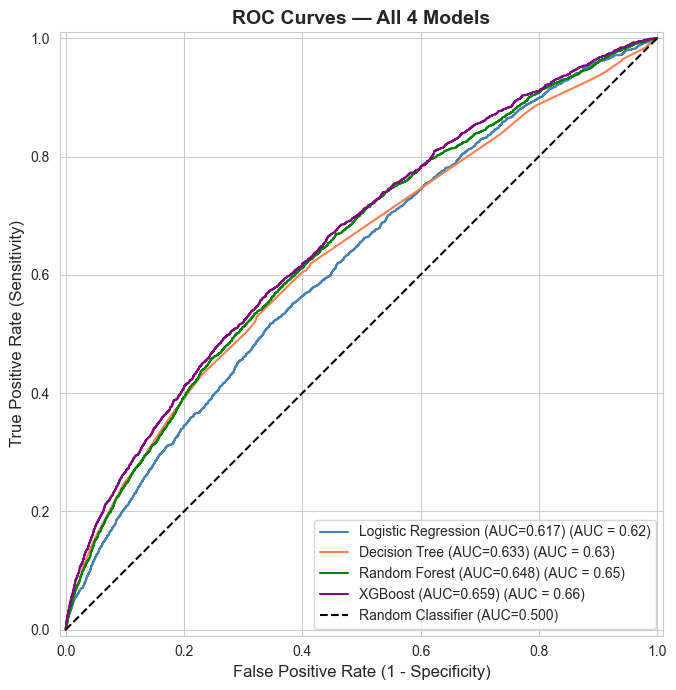

ROC curve saved!


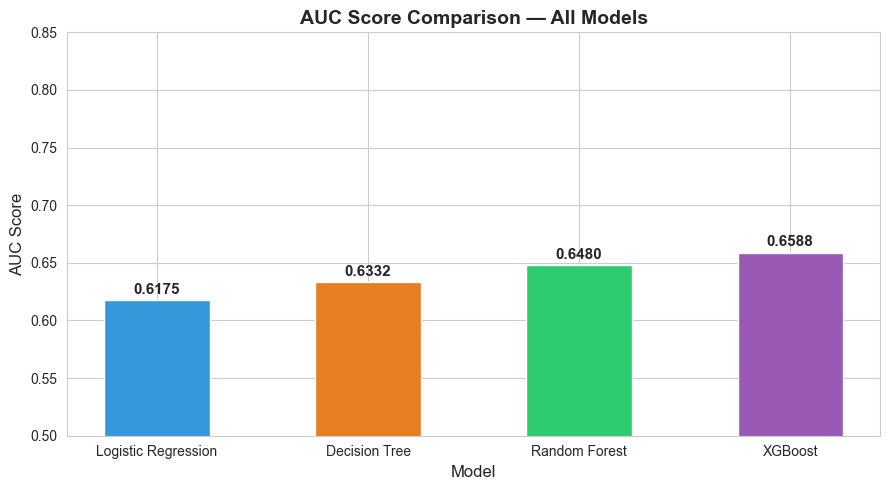

AUC comparison chart saved!


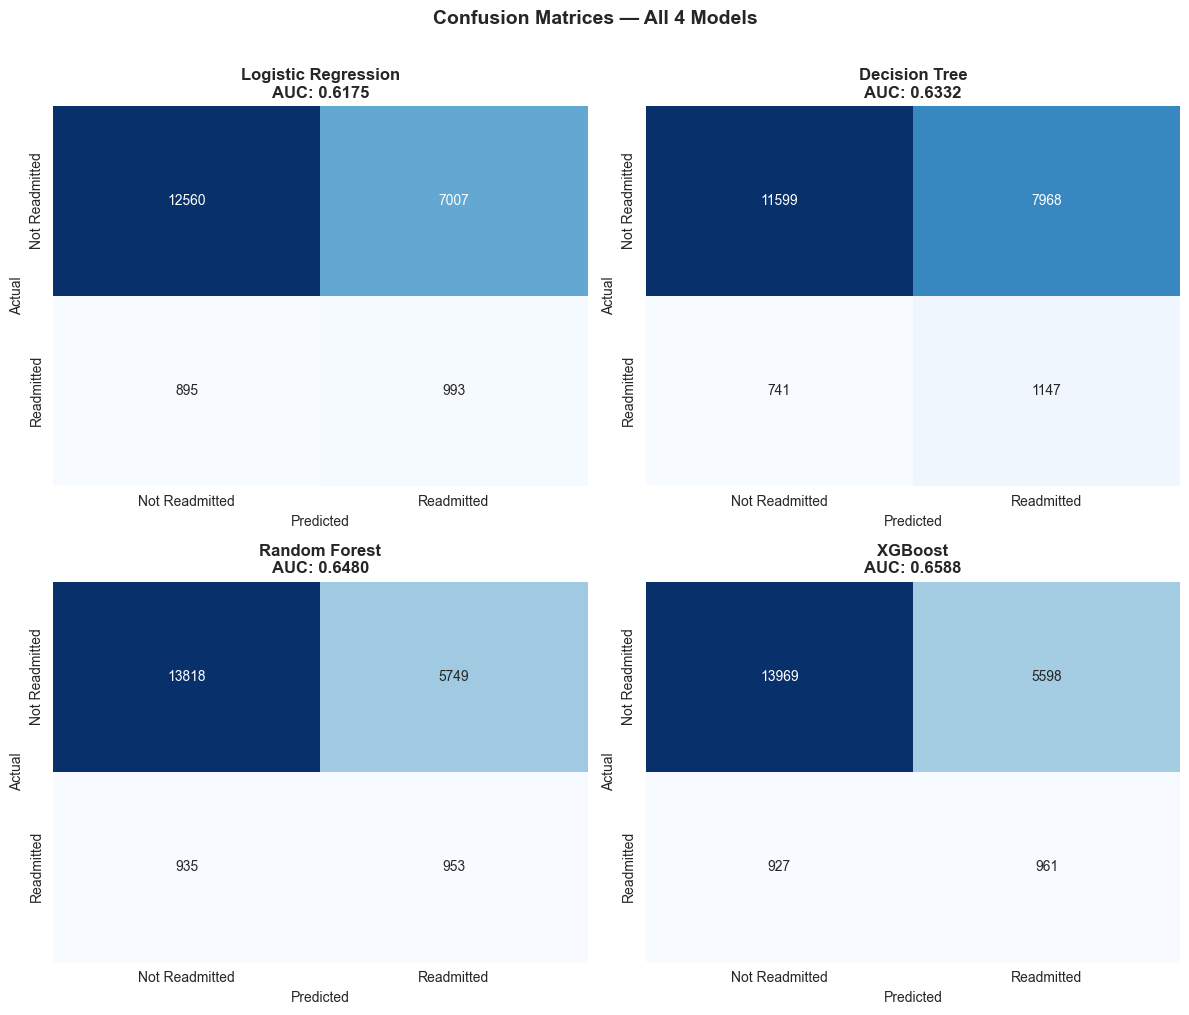

Confusion matrices saved!

PHASE 4 COMPLETE!


In [9]:
# ============================================================
# PHASE 4 — MODEL BUILDING & EVALUATION
# We build 4 models and compare them all
# Goal: find which model best predicts readmission
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── IMPORTANT: class_weight='balanced' ────────────────────
# Remember our data has 8.8% readmitted vs 91.2% not
# Without this, models just predict 'No' for everyone
# class_weight='balanced' forces models to pay equal
# attention to both classes regardless of their frequency

# We store all results here to compare at the end
results = {}

print("="*55)
print("BUILDING ALL 4 MODELS...")
print("="*55)

# ── MODEL 1: LOGISTIC REGRESSION ──────────────────────────
# The simplest model — our baseline
# Think of it as a weighted checklist:
# each feature gets a score (coefficient)
# scores are added up → converted to a probability
# Easy to interpret: "being in hospital 7+ days
# increases readmission odds by X%"

print("\n[1/4] Training Logistic Regression...")

lr = LogisticRegression(
    class_weight='balanced',  # handle imbalance
    max_iter=1000,            # give it enough iterations to converge
    random_state=42
)
lr.fit(X_train, y_train)

# Predict probabilities (not just 0/1)
# We use probabilities to calculate AUC
lr_probs = lr.predict_proba(X_test)[:, 1]
lr_preds = lr.predict(X_test)
lr_auc   = roc_auc_score(y_test, lr_probs)

results['Logistic Regression'] = {
    'model': lr,
    'probs': lr_probs,
    'preds': lr_preds,
    'auc':   lr_auc
}
print(f"    Logistic Regression AUC: {lr_auc:.4f}")

# ── MODEL 2: DECISION TREE ────────────────────────────────
# A flowchart of yes/no questions
# "Is time_in_hospital > 5? If yes → Is num_medications > 10?"
# Very visual and easy to explain to doctors
# We limit depth to avoid overfitting (memorizing training data)

print("\n[2/4] Training Decision Tree...")

dt = DecisionTreeClassifier(
    max_depth=6,              # limit tree depth to avoid overfitting
    min_samples_leaf=50,      # each leaf must have at least 50 patients
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)

dt_probs = dt.predict_proba(X_test)[:, 1]
dt_preds = dt.predict(X_test)
dt_auc   = roc_auc_score(y_test, dt_probs)

results['Decision Tree'] = {
    'model': dt,
    'probs': dt_probs,
    'preds': dt_preds,
    'auc':   dt_auc
}
print(f"    Decision Tree AUC: {dt_auc:.4f}")

# ── MODEL 3: RANDOM FOREST ────────────────────────────────
# Builds 300 decision trees, each on a random subset of data
# Final prediction = majority vote across all 300 trees
# Much more powerful than a single tree
# Less likely to overfit because errors average out
# This is our expected best model based on prior coursework

print("\n[3/4] Training Random Forest (this takes ~1-2 min)...")

rf = RandomForestClassifier(
    n_estimators=300,         # build 300 trees
    max_depth=10,             # each tree goes 10 levels deep
    max_features='sqrt',      # each tree sees sqrt(44) ≈ 6 random features
                              # this forces diversity across trees
    min_samples_leaf=30,      # each leaf needs 30+ patients
    class_weight='balanced',
    random_state=42,
    n_jobs=-1                 # use all CPU cores → faster training
)
rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]
rf_preds = rf.predict(X_test)
rf_auc   = roc_auc_score(y_test, rf_probs)

results['Random Forest'] = {
    'model': rf,
    'probs': rf_probs,
    'preds': rf_preds,
    'auc':   rf_auc
}
print(f"    Random Forest AUC: {rf_auc:.4f}")

# ── MODEL 4: GRADIENT BOOSTING (XGBoost) ─────────────────
# Also builds many trees but differently from Random Forest
# Each new tree CORRECTS the mistakes of the previous tree
# Learns sequentially rather than independently
# Very powerful — often wins data science competitions

print("\n[4/4] Training Gradient Boosting (this takes ~1-2 min)...")

from xgboost import XGBClassifier

# Calculate scale_pos_weight for XGBoost imbalance handling
# = number of negatives / number of positives
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"    scale_pos_weight = {scale:.1f} (handles 8.8% imbalance)")

xgb = XGBClassifier(
    n_estimators=300,         # 300 boosting rounds
    max_depth=5,              # shallower trees work better for boosting
    learning_rate=0.05,       # small steps → more careful learning
    subsample=0.8,            # each tree uses 80% of training data
    colsample_bytree=0.8,     # each tree uses 80% of features
    scale_pos_weight=scale,   # handles class imbalance for XGBoost
    random_state=42,
    eval_metric='auc',
    verbosity=0               # suppress XGBoost output
)
xgb.fit(X_train, y_train)

xgb_probs = xgb.predict_proba(X_test)[:, 1]
xgb_preds = xgb.predict(X_test)
xgb_auc   = roc_auc_score(y_test, xgb_probs)

results['XGBoost'] = {
    'model': xgb,
    'probs': xgb_probs,
    'preds': xgb_preds,
    'auc':   xgb_auc
}
print(f"    XGBoost AUC: {xgb_auc:.4f}")

# ── RESULTS COMPARISON TABLE ──────────────────────────────
print("\n" + "="*55)
print("MODEL COMPARISON — AUC SCORES")
print("="*55)
print(f"{'Model':<25} {'AUC Score':>10}")
print("-"*55)
for name, res in sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True):
    marker = " ← BEST" if res['auc'] == max(r['auc'] for r in results.values()) else ""
    print(f"{name:<25} {res['auc']:>10.4f}{marker}")

# ── PLOT: ROC CURVES FOR ALL 4 MODELS ────────────────────
# ROC curve shows the tradeoff between:
#   Sensitivity (catching real readmissions)
#   Specificity (not falsely flagging healthy patients)
# The closer the curve hugs the top-left corner = better model
# AUC = area under this curve (1.0 = perfect, 0.5 = random)

plt.figure(figsize=(9, 7))
colors = ['steelblue', 'coral', 'green', 'purple']
for (name, res), color in zip(results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_test, res['probs'],
        name=f"{name} (AUC={res['auc']:.3f})",
        color=color,
        ax=plt.gca()
    )

plt.plot([0,1],[0,1],'k--', label='Random Classifier (AUC=0.500)')
plt.title('ROC Curves — All 4 Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/fig8_roc_curves.png', dpi=150)
plt.show()
print("ROC curve saved!")

# ── PLOT: AUC BAR CHART ───────────────────────────────────
plt.figure(figsize=(9, 5))
model_names = list(results.keys())
auc_scores  = [results[m]['auc'] for m in model_names]
colors_bar  = ['#3498db','#e67e22','#2ecc71','#9b59b6']

bars = plt.bar(model_names, auc_scores, color=colors_bar,
               edgecolor='white', width=0.5)
plt.ylim(0.5, 0.85)
plt.title('AUC Score Comparison — All Models', fontsize=14, fontweight='bold')
plt.ylabel('AUC Score', fontsize=12)
plt.xlabel('Model', fontsize=12)

for bar, score in zip(bars, auc_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f'{score:.4f}',
             ha='center', va='bottom',
             fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('outputs/fig9_auc_comparison.png', dpi=150)
plt.show()
print("AUC comparison chart saved!")

# ── CONFUSION MATRICES FOR ALL 4 MODELS ──────────────────
# Confusion matrix shows:
#   True Positives  = correctly caught readmissions
#   False Negatives = missed readmissions (dangerous!)
#   False Positives = falsely flagged patients
#   True Negatives  = correctly cleared patients

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[idx], cbar=False,
                xticklabels=['Not Readmitted','Readmitted'],
                yticklabels=['Not Readmitted','Readmitted'])
    axes[idx].set_title(f'{name}\nAUC: {res["auc"]:.4f}',
                        fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('Actual', fontsize=10)
    axes[idx].set_xlabel('Predicted', fontsize=10)

plt.suptitle('Confusion Matrices — All 4 Models',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/fig10_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved!")

print("\n================================================")
print("PHASE 4 COMPLETE!")
print("================================================")

Generating Variable Importance plots...


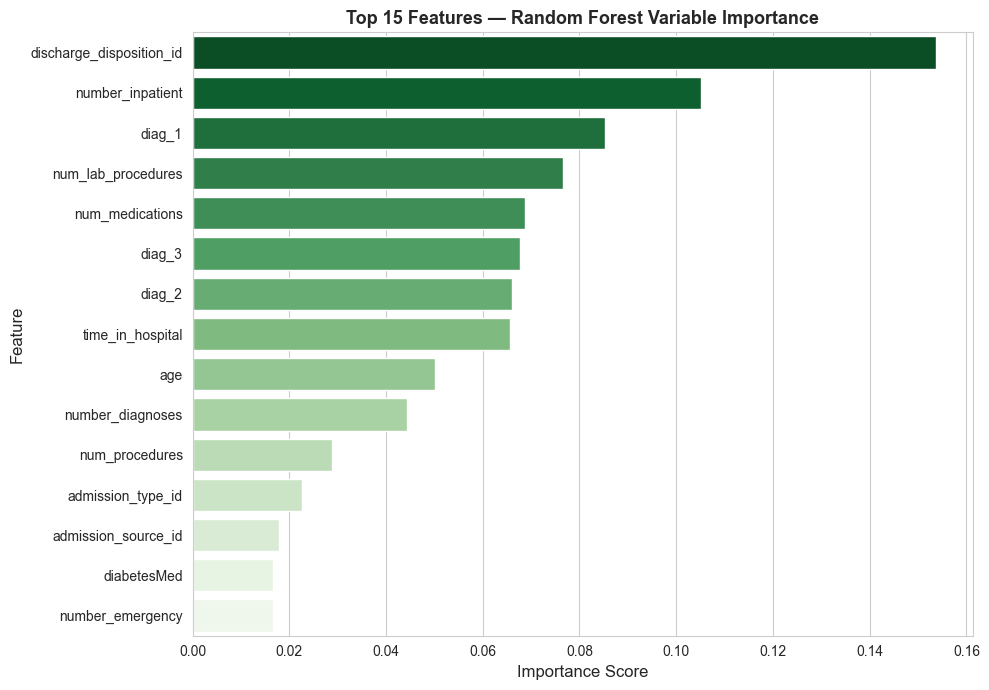

Plot saved: RF Variable Importance


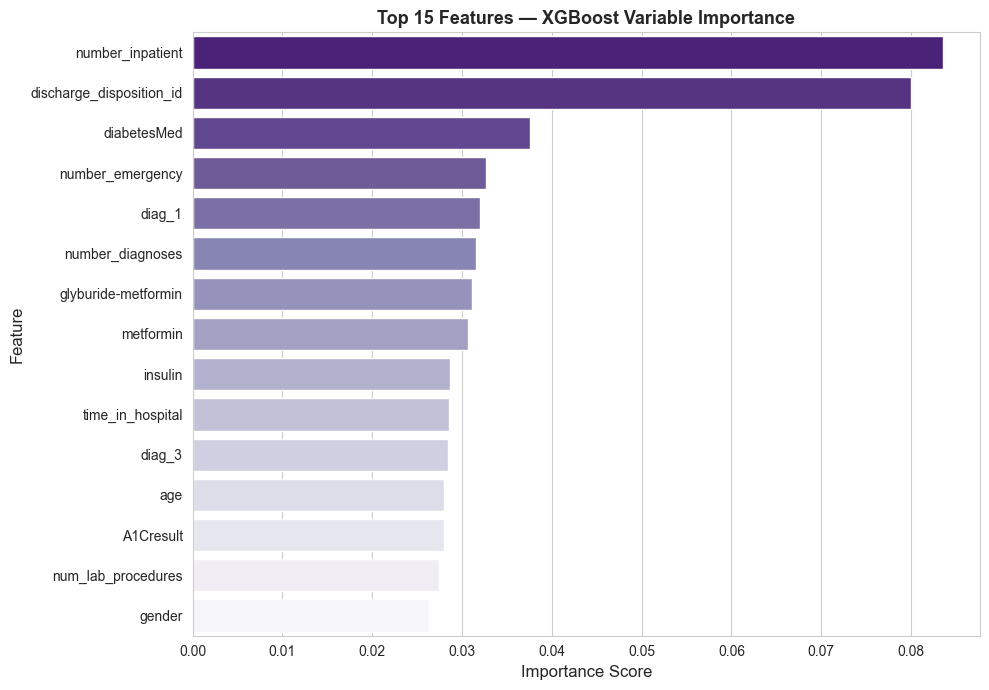

Plot saved: XGBoost Variable Importance

Features important in BOTH models: {'number_inpatient', 'discharge_disposition_id', 'diag_1', 'time_in_hospital', 'number_diagnoses'}


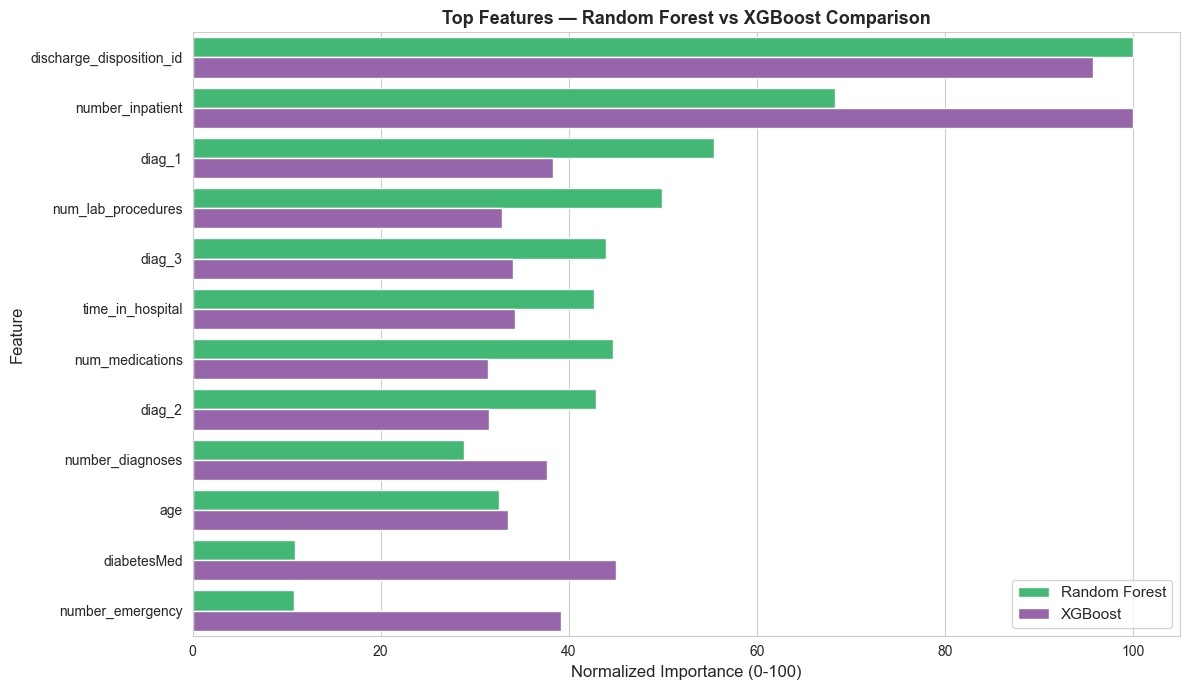

Plot saved: Side-by-side importance comparison


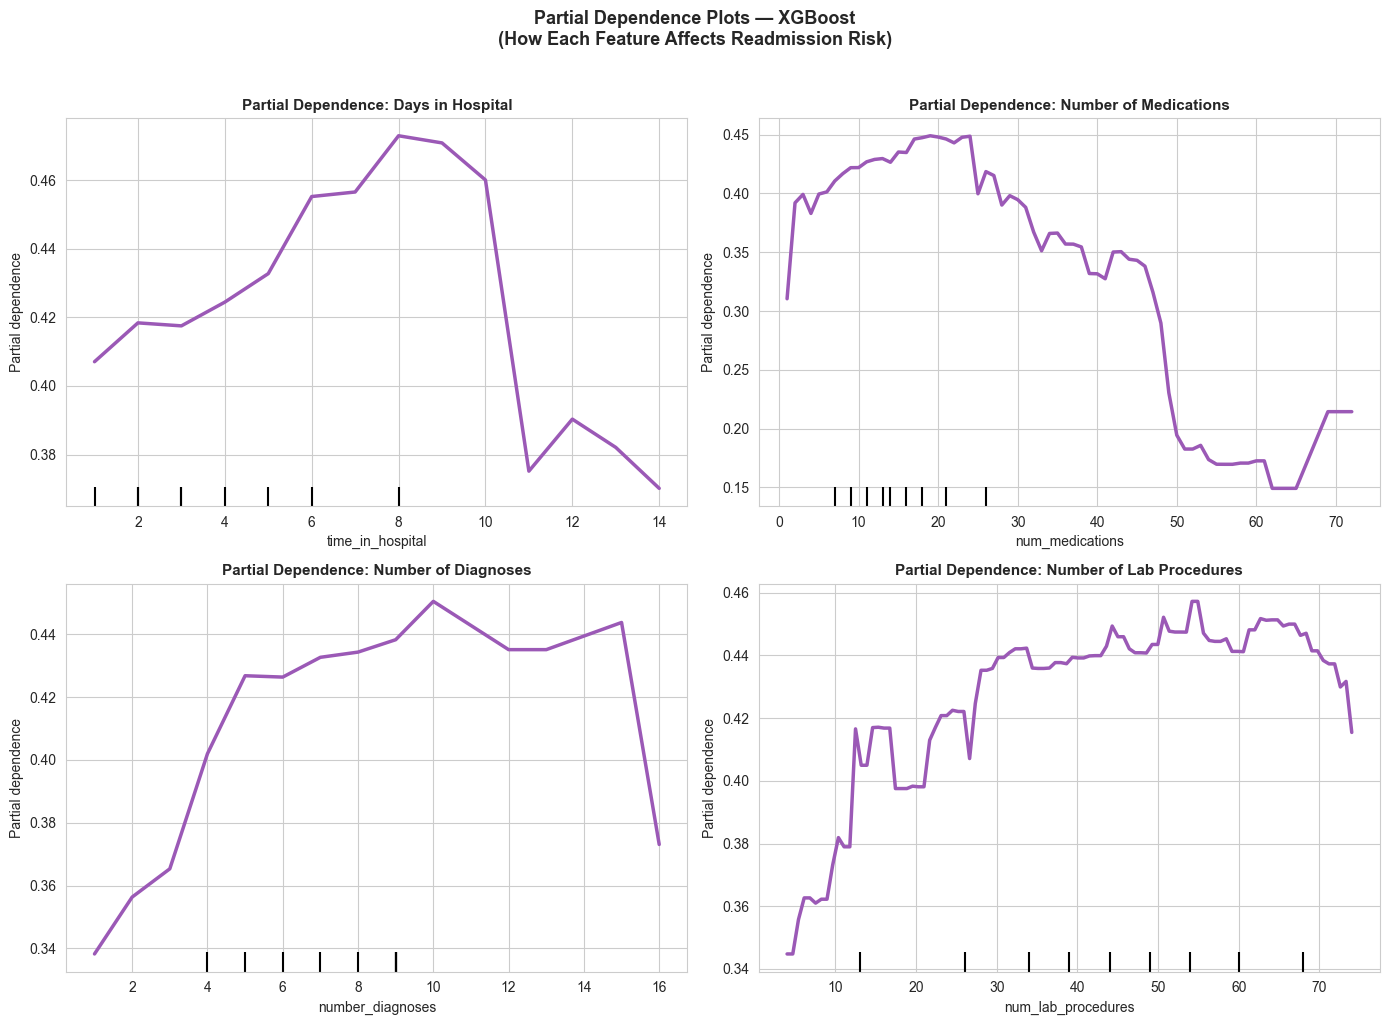

Plot saved: Partial Dependence Plots

PRESCRIPTIVE CLINICAL RECOMMENDATIONS
Based on XGBoost + Random Forest analysis

[1] TIME IN HOSPITAL vs READMISSION RATE:
 Days  Readmission Rate %  Patient Count
    1                 6.4          10715
    2                 7.6          12397
    3                 8.1          12701
    4                 8.7           9567
    5                 9.6           6839
    6                10.7           5171
    7                11.2           3999
    8                12.0           2918
    9                11.9           1990
   10                11.9           1558
   11                 9.3           1241
   12                11.9            955
   13                10.1            795
   14                11.1            669

[2] A1C TEST RESULT vs READMISSION RATE:
A1C Result  Readmission Rate %  Patient Count
        >7                 8.5           2891
      Norm                 8.5           3791
        >8                 8.1           630

In [10]:
# ============================================================
# PHASE 5 — VARIABLE IMPORTANCE & PRESCRIPTIVE LAYER
# Goal: Understand WHAT drives readmission and
#       WHAT clinicians should do differently at discharge
# This is what separates your project from everyone else
# ============================================================

# ── PLOT 1: Random Forest Variable Importance ─────────────
# Feature importance = how much each feature REDUCES error
# across all 300 trees in the forest
# Higher = more important for predicting readmission

print("Generating Variable Importance plots...")

# Get feature importances from Random Forest
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=rf_importance, x='Importance', y='Feature',
            palette='Greens_r')
plt.title('Top 15 Features — Random Forest Variable Importance',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/fig11_rf_importance.png', dpi=150)
plt.show()
print("Plot saved: RF Variable Importance")

# ── PLOT 2: XGBoost Variable Importance ───────────────────
# XGBoost importance = how often a feature is used to split
# across all 300 boosting rounds
# Compare with RF — if same features appear in both → very reliable

xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=xgb_importance, x='Importance', y='Feature',
            palette='Purples_r')
plt.title('Top 15 Features — XGBoost Variable Importance',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/fig12_xgb_importance.png', dpi=150)
plt.show()
print("Plot saved: XGBoost Variable Importance")

# ── PLOT 3: Side-by-Side Importance Comparison ────────────
# Shows which features BOTH models agree on
# Agreement between RF and XGBoost = strong evidence
# these features genuinely drive readmission

# Get top 10 from each
top_rf  = set(rf_importance.head(10)['Feature'].values)
top_xgb = set(xgb_importance.head(10)['Feature'].values)
common  = top_rf.intersection(top_xgb)
print(f"\nFeatures important in BOTH models: {common}")

# Normalize importances to 0-100 scale for fair comparison
rf_imp_norm = pd.DataFrame({
    'Feature': X.columns,
    'RF_Importance': rf.feature_importances_ / rf.feature_importances_.max() * 100
})
xgb_imp_norm = pd.DataFrame({
    'Feature': X.columns,
    'XGB_Importance': xgb.feature_importances_ / xgb.feature_importances_.max() * 100
})

# Merge and get top 12 by average importance
combined = rf_imp_norm.merge(xgb_imp_norm, on='Feature')
combined['Avg_Importance'] = (combined['RF_Importance'] + combined['XGB_Importance']) / 2
combined = combined.sort_values('Avg_Importance', ascending=False).head(12)

# Melt for seaborn grouped bar chart
combined_melted = combined.melt(
    id_vars='Feature',
    value_vars=['RF_Importance', 'XGB_Importance'],
    var_name='Model',
    value_name='Importance (Normalized)'
)
combined_melted['Model'] = combined_melted['Model'].map({
    'RF_Importance': 'Random Forest',
    'XGB_Importance': 'XGBoost'
})

plt.figure(figsize=(12, 7))
sns.barplot(data=combined_melted, x='Importance (Normalized)',
            y='Feature', hue='Model',
            palette=['#2ecc71', '#9b59b6'])
plt.title('Top Features — Random Forest vs XGBoost Comparison',
          fontsize=13, fontweight='bold')
plt.xlabel('Normalized Importance (0-100)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('outputs/fig13_importance_comparison.png', dpi=150)
plt.show()
print("Plot saved: Side-by-side importance comparison")

# ── PLOT 4: Partial Dependence Plots ──────────────────────
# This is the PRESCRIPTIVE layer — the most important part
# Partial dependence shows: if we change ONE feature,
# how does the predicted readmission probability change?
# Everything else is held constant
# This directly tells clinicians: "change THIS to reduce risk"

from sklearn.inspection import PartialDependenceDisplay

# Top 4 most important numeric features to analyze
# (these are the ones clinicians can actually influence)
top_numeric_features = ['time_in_hospital', 'num_medications',
                         'number_diagnoses', 'num_lab_procedures']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

feature_labels = {
    'time_in_hospital':   'Days in Hospital',
    'num_medications':    'Number of Medications',
    'number_diagnoses':   'Number of Diagnoses',
    'num_lab_procedures': 'Number of Lab Procedures'
}

for idx, feature in enumerate(top_numeric_features):
    feat_idx = list(X.columns).index(feature)
    PartialDependenceDisplay.from_estimator(
        xgb, X_test, [feat_idx],
        ax=axes_flat[idx],
        line_kw={'color': '#9b59b6', 'linewidth': 2.5}
    )
    axes_flat[idx].set_title(
        f'Partial Dependence: {feature_labels[feature]}',
        fontweight='bold', fontsize=11
    )
    axes_flat[idx].set_xlabel(feature_labels[feature], fontsize=10)
    axes_flat[idx].set_ylabel('Predicted Readmission\nProbability', fontsize=10)

plt.suptitle('Partial Dependence Plots — XGBoost\n(How Each Feature Affects Readmission Risk)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/fig14_partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: Partial Dependence Plots")

# ── PRESCRIPTIVE RECOMMENDATIONS ──────────────────────────
# This is the clinical translation layer
# We look at actual readmission rates across feature values
# and generate ranked recommendations for discharge planners

print("\n" + "="*60)
print("PRESCRIPTIVE CLINICAL RECOMMENDATIONS")
print("Based on XGBoost + Random Forest analysis")
print("="*60)

# Recommendation 1: Time in Hospital
print("\n[1] TIME IN HOSPITAL vs READMISSION RATE:")
time_analysis = df.groupby('time_in_hospital')['readmitted_binary'].agg(
    ['mean', 'count']).reset_index()
time_analysis['mean'] = (time_analysis['mean'] * 100).round(1)
time_analysis.columns = ['Days', 'Readmission Rate %', 'Patient Count']
print(time_analysis.to_string(index=False))

# Recommendation 2: A1C Testing
print("\n[2] A1C TEST RESULT vs READMISSION RATE:")
# Decode A1C back for readability
df_temp = pd.read_csv('data/diabetic_data.csv', na_values='?')
df_temp = df_temp[df_temp['encounter_id'].isin(
    pd.read_csv('data/diabetic_data.csv', na_values='?')
    .groupby('patient_nbr')['encounter_id'].min().values
)]
df_temp['readmitted_binary'] = (df_temp['readmitted'] == '<30').astype(int)
a1c_analysis = df_temp.groupby('A1Cresult')['readmitted_binary'].agg(
    ['mean','count']).reset_index()
a1c_analysis['mean'] = (a1c_analysis['mean'] * 100).round(1)
a1c_analysis.columns = ['A1C Result', 'Readmission Rate %', 'Patient Count']
print(a1c_analysis.sort_values('Readmission Rate %', ascending=False).to_string(index=False))

# Recommendation 3: Medication Changes
print("\n[3] INSULIN ADJUSTMENT vs READMISSION RATE:")
insulin_analysis = df_temp.groupby('insulin')['readmitted_binary'].agg(
    ['mean','count']).reset_index()
insulin_analysis['mean'] = (insulin_analysis['mean'] * 100).round(1)
insulin_analysis.columns = ['Insulin Status', 'Readmission Rate %', 'Patient Count']
print(insulin_analysis.sort_values('Readmission Rate %', ascending=False).to_string(index=False))

# Recommendation 4: Number of Medications
print("\n[4] NUMBER OF MEDICATIONS vs READMISSION RATE:")
med_bins = pd.cut(df['num_medications'],
                   bins=[0, 5, 10, 15, 20, 100],
                   labels=['1-5 meds', '6-10 meds', '11-15 meds',
                           '16-20 meds', '20+ meds'])
med_analysis = df.groupby(med_bins, observed=True)['readmitted_binary'].agg(
    ['mean','count']).reset_index()
med_analysis['mean'] = (med_analysis['mean'] * 100).round(1)
med_analysis.columns = ['Medication Range', 'Readmission Rate %', 'Patient Count']
print(med_analysis.to_string(index=False))

print("\n" + "="*60)
print("PHASE 5 COMPLETE!")
print("="*60)

In [12]:
# ============================================================
# PHASE 6 — SAVE ALL RESULTS FOR DOCUMENTATION
# Run this now so nothing is lost
# ============================================================

import json

# Save model AUC scores
model_results = {
    'Logistic Regression': float(results['Logistic Regression']['auc']),
    'Decision Tree':       float(results['Decision Tree']['auc']),
    'Random Forest':       float(results['Random Forest']['auc']),
    'XGBoost':             float(results['XGBoost']['auc'])
}

with open('outputs/model_results.json', 'w') as f:
    json.dump(model_results, f, indent=2)

# Save feature importances
rf_importance.to_csv('outputs/rf_importance.csv', index=False)
xgb_importance.to_csv('outputs/xgb_importance.csv', index=False)

# Save prescriptive tables
time_analysis.to_csv('outputs/rec1_time_in_hospital.csv', index=False)
a1c_analysis.to_csv('outputs/rec2_a1c_analysis.csv', index=False)
insulin_analysis.to_csv('outputs/rec3_insulin_analysis.csv', index=False)
med_analysis.to_csv('outputs/rec4_medications.csv', index=False)

# Save cleaned dataset
df.to_csv('outputs/cleaned_data.csv', index=False)

print("All results saved to outputs/ folder!")
print("\nFiles saved:")
import os
for f in sorted(os.listdir('outputs/')):
    size = os.path.getsize(f'outputs/{f}')
    print(f"  {f:45s} {size:>8,} bytes")

All results saved to outputs/ folder!

Files saved:
  cleaned_data.csv                              7,045,641 bytes
  fig10_confusion_matrices.png                    94,510 bytes
  fig11_rf_importance.png                         67,196 bytes
  fig12_xgb_importance.png                        62,030 bytes
  fig13_importance_comparison.png                 67,411 bytes
  fig14_partial_dependence.png                   196,214 bytes
  fig1_target_distribution.png                    45,845 bytes
  fig2_readmission_by_time.png                    33,565 bytes
  fig3_readmission_by_medications.png             74,836 bytes
  fig4_readmission_by_a1c.png                     31,583 bytes
  fig5_readmission_by_discharge.png               74,330 bytes
  fig6_correlation_heatmap.png                   107,915 bytes
  fig7_readmission_by_diagnoses.png               40,649 bytes
  fig8_roc_curves.png                            130,818 bytes
  fig9_auc_comparison.png                         44,273 bytes
  